In [25]:
import sys
print(sys.executable)

/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/.conda/bin/python


In [26]:
import os
import pandas as pd 
import numpy as np

In [27]:
active_subjects = pd.read_csv(os.path.join("..", "..","data", "active_subjects.csv"))
audiences = pd.read_csv(os.path.join("..", "..","data", 'audiencies.csv'))
institutions = pd.read_csv(os.path.join("..", "..","data", 'institutions.csv'))
passive_subjects = pd.read_csv(os.path.join("..", "..","data", 'passive_subjects.csv'))

In [28]:
df_grande = pd.merge(
    active_subjects,
    audiences,
    on='audiencia_id',
    how='inner'  # solo registros que existen en ambos
)

In [29]:
df = df_grande.copy()
df = df[['sujeto_pasivo_id_x','Nombre completo','materias_tratadas','especificacion']]
df = df.rename(columns={
    'sujeto_pasivo_id_x': 'pasivo_id',
    'Nombre completo': 'activo_id',
    'materias_tratadas': 'temas',
    'especificacion': 'detalle'
})

In [40]:
df['detalle'][122]

'posibilidad de electrificación en sector Barrio Alto Comuna de Canela'

La columna de detalle es la que mas me puede caracterizar el problema

In [35]:
df.head()

,pasivo_id,activo_id,temas,detalle
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...


In [36]:
ruta = os.path.join("emb_detalle", "emb_detalle_full.npy")

# Cargar el embeding
emb_detalle = np.load(ruta)

print("Embeddings cargados con éxito.")
print("Shape:", emb_detalle.shape)
print("Dimensiones por embedding:", emb_detalle.shape[1])

Embeddings cargados con éxito.
Shape: (1153810, 768)
Dimensiones por embedding: 768


In [8]:
ruta = os.path.join("emb_temas", "emb_temas_full.npy")
emb_temas = np.load(ruta)

print("Embeddings de temas cargados correctamente.")
print("Shape:", emb_temas.shape)

Embeddings de temas cargados correctamente.
Shape: (1153810, 768)


## Hacer PCA para reducir dimensiones

In [41]:
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA


# 1. Usamos SOLO el detalle
# Normalizamos para que la longitud del texto no afecte
print("Normalizando solo Detalle...")
emb_input = normalize(emb_detalle) 

# 2. PCA (Sobre solo detalle)
# Esto limpiará el ruido de palabras comunes como "el", "la", etc.
pca = PCA(n_components=50, random_state=42)
emb_50 = pca.fit_transform(emb_input)



print("Dimensiones finales para clustering:", emb_50.shape)
# Resultado: (N_docs, 50) -> Listo para UMAP + HDBSCAN

Normalizando solo Detalle...
Dimensiones finales para clustering: (1153810, 50)


# HACER KNN

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

from tqdm import tqdm


In [ ]:
Ks = [20, 30, 40, 50, 60, 80, 100]

inertia_list = []
silhouette_list = []
davies_list = []
ari_list = []


In [ ]:
import numpy as np

sample_size = 50000
indices = np.random.choice(len(emb_total_50), size=sample_size, replace=False)

emb_sample = emb_total_50[indices]


In [ ]:
Ks = [20, 30, 40, 50, 60, 80, 100]

inertia_list = []
silhouette_list = []
davies_list = []
ari_list = []

from tqdm import tqdm
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

print("Evaluando distintos valores de K (usando muestra)...\n")

for k in tqdm(Ks, desc="Probando K"):
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=5000,
        random_state=42
    )
    labels = kmeans.fit_predict(emb_sample)

    inertia = kmeans.inertia_
    sil = silhouette_score(emb_sample, labels)
    db = davies_bouldin_score(emb_sample, labels)

    # Estabilidad
    km1 = MiniBatchKMeans(n_clusters=k, random_state=0)
    km2 = MiniBatchKMeans(n_clusters=k, random_state=1)

    l1 = km1.fit_predict(emb_sample)
    l2 = km2.fit_predict(emb_sample)
    ari = adjusted_rand_score(l1, l2)

    inertia_list.append(inertia)
    silhouette_list.append(sil)
    davies_list.append(db)
    ari_list.append(ari)


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].plot(Ks, inertia_list, marker='o')
axs[0, 0].set_title("Elbow (Inercia)")
axs[0, 0].set_xlabel("K")
axs[0, 0].set_ylabel("Inercia")

axs[0, 1].plot(Ks, silhouette_list, marker='o')
axs[0, 1].set_title("Silhouette Score")
axs[0, 1].set_xlabel("K")
axs[0, 1].set_ylabel("Silhouette")

axs[1, 0].plot(Ks, davies_list, marker='o')
axs[1, 0].set_title("Davies-Bouldin Index")
axs[1, 0].set_xlabel("K")
axs[1, 0].set_ylabel("DB Index")

axs[1, 1].plot(Ks, ari_list, marker='o')
axs[1, 1].set_title("ARI (Estabilidad)")
axs[1, 1].set_xlabel("K")
axs[1, 1].set_ylabel("ARI")

plt.tight_layout()
plt.show()


In [ ]:
df_metrics = pd.DataFrame({
    "K": Ks,
    "Inercia": inertia_list,
    "Silhouette": silhouette_list,
    "DaviesBouldin": davies_list,
    "ARI": ari_list
})

df_metrics["rank_inercia"] = df_metrics["Inercia"].rank(ascending=True)
df_metrics["rank_sil"] = df_metrics["Silhouette"].rank(ascending=False)
df_metrics["rank_db"] = df_metrics["DaviesBouldin"].rank(ascending=True)
df_metrics["rank_ari"] = df_metrics["ARI"].rank(ascending=False)

df_metrics["rank_total"] = df_metrics[[
    "rank_inercia", "rank_sil", "rank_db", "rank_ari"
]].mean(axis=1)

df_metrics_sorted = df_metrics.sort_values("rank_total")

print("\nRanking final del mejor K:")
print(df_metrics_sorted)


In [ ]:
from sklearn.cluster import MiniBatchKMeans
from tqdm import tqdm

# Número de clusters óptimo encontrado
best_K = 20

print(f"Entrenando KMeans final con K={best_K} sobre TODO el dataset...\n")

kmeans_final = MiniBatchKMeans(
    n_clusters=best_K,
    batch_size=50000,     # puedes subir a 50,000 si tu RAM lo permite
    random_state=42,
    verbose=0
)

# Entrenar y predecir cluster para cada embedding
cluster_labels = kmeans_final.fit_predict(emb_total_50)

print("Clustering final terminado.")
print("Tamaño del resultado:", cluster_labels.shape)


In [ ]:
# Si quiero agregar los clusters al dataframe
#df["cluster_k20"] = cluster_labels


In [ ]:
import numpy as np
import pandas as pd

unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_sizes = pd.DataFrame({"cluster": unique, "count": counts}).sort_values("cluster")

print(cluster_sizes)


In [ ]:
def mostrar_ejemplos_cluster(df, cluster_id, n=10):
    subset = df[df["cluster_k20"] == cluster_id].head(n)
    print(f"\n=== Ejemplos cluster {cluster_id} ===\n")
    for i, row in subset.iterrows():
        print(f"- {row['temas']}")
        # Si quieres agregar detalle:
        print(f"  Detalle: {row['detalle']}\n")


In [ ]:
mostrar_ejemplos_cluster(df, cluster_id=2, n=10)


In [ ]:
from collections import Counter
import re

def palabras_cluster(df, cluster_id, top_n=20):
    subset = df[df["cluster_k20"] == cluster_id]
    textos = (subset["temas"].fillna("") + " " + subset["detalle"].fillna("")).tolist()

    corpus = " ".join(textos).lower()

    # limpieza simple
    corpus = re.sub(r"[^a-zA-Záéíóúñ0-9\s]", " ", corpus)
    tokens = corpus.split()

    # eliminar stopwords (opcional)
    stopwords = {"de","la","el","en","y","del","por","para","un","una","los","las","con","sobre","tambien","sujetos","pasivos",
    "tomen","tambien","evaluación"}
    tokens = [t for t in tokens if t not in stopwords and len(t) > 3]

    counter = Counter(tokens)
    return counter.most_common(top_n)


In [ ]:
palabras_cluster(df, 0, top_n=20)


In [ ]:
df

In [ ]:
df["pasivo_id"] = df["pasivo_id"].astype(str)
df["activo_id"] = df["activo_id"].astype(str)
df["cluster_k20"] = df["cluster_k20"].astype(str)


# UMAP en vez de KNN

In [11]:
total_docs = len(emb_50)

sample_size = 50000 

if total_docs > sample_size:

    print(f"Haciendo sampling de {sample_size} documentos...")

    indices = np.random.choice(total_docs, size=sample_size, replace=False)

    emb_input = emb_50[indices]

else:

    emb_input = emb_50

    indices = np.arange(total_docs)

Haciendo sampling de 50000 documentos...


In [12]:
import umap
import hdbscan
import pandas as pd

# ==========================================
# 1. UMAP: Estrategia "Fragmentación Local"
# ==========================================
print("Recalculando UMAP (n_neighbors=5 para romper puentes)...")

# Asumimos que emb_50 (tu PCA) sigue en memoria
umap_embeddings = umap.UMAP(
    n_neighbors=5,      # <--- CAMBIO CRÍTICO: Bajamos de 15 a 5. 
                        # Esto prioriza la estructura local y rompe conexiones globales débiles.
    n_components=5,
    min_dist=0.0,       # Queremos clusters ultra compactos
    metric='cosine',
    random_state=42,
    n_jobs=1            # Por seguridad en Mac
).fit_transform(emb_input) # Ojo: usa emb_50 (el PCA de solo detalles)

# ==========================================
# 2. HDBSCAN: Vuelta a la normalidad ('eom')
# ==========================================
# Como UMAP ya separó las islas, HDBSCAN puede trabajar normal sin ser destructivo.
print("Ejecutando HDBSCAN...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40, # Tamaño mínimo para ser un tema
    min_samples=10,      # Sensibilidad equilibrada
    metric='euclidean',
    cluster_selection_method='eom', # Volvemos a 'eom' (Mass), 'leaf' fue demasiado.
    prediction_data=True
)

labels = clusterer.fit_predict(umap_embeddings)

# ==========================================
# 3. RESULTADOS
# ==========================================
df_results = pd.DataFrame({'cluster': labels})
conteo = df_results['cluster'].value_counts().sort_index()
ruido = (conteo.get(-1, 0) / len(labels)) * 100
top_cluster_pct = (df_results['cluster'].value_counts().iloc[0] / len(labels)) * 100

print(f"\n--- Resultados Estrategia 'Vecinos Cercanos' ---")
print(f"Total Clusters: {len(conteo)-1}")
print(f"Ruido: {ruido:.2f}% (Buscamos entre 15-30%)")
print(f"El cluster más grande tiene: {top_cluster_pct:.2f}% (Meta: <15%)")

print("\nTop 10 Clusters:")
print(df_results['cluster'].value_counts().head(10))


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Recalculando UMAP (n_neighbors=5 para romper puentes)...
Ejecutando HDBSCAN...


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/.conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/.conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- Resultados Estrategia 'Vecinos Cercanos' ---
Total Clusters: 112
Ruido: 22.67% (Buscamos entre 15-30%)
El cluster más grande tiene: 28.06% (Meta: <15%)

Top 10 Clusters:
cluster
 12     14030
-1      11334
 38      5139
 77      1513
 26      1306
 66      1081
 33      1023
 36       817
 103      702
 15       657
Name: count, dtype: int64


In [15]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# Definimos la lista de Stop Words en Español manualmente
spanish_stop_words = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 
    'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 
    'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 
    'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 
    'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 
    'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 
    'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 
    'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 
    'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 
    'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 
    'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 
    'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 
    'vuestra', 'vuestros', 'vuestras', 'esos', 'esas', 'estoy', 'estás', 'está', 
    'estamos', 'estáis', 'están', 'esté', 'estés', 'estemos', 'estéis', 'estén', 
    'estaré', 'estarás', 'estará', 'estaremos', 'estaréis', 'estarán', 'estaría', 
    'estarías', 'estaríamos', 'estaríais', 'estarían', 'estaba', 'estabas', 
    'estábamos', 'estabais', 'estaban', 'estuve', 'estuviste', 'estuvo', 
    'estuvimos', 'estuvisteis', 'estuvieron', 'hubiera', 'hubieras', 'hubiéramos', 
    'hubierais', 'hubieran', 'hubiese', 'hubieses', 'hubiésemos', 'hubieseis', 
    'hubiesen', 'habiendo', 'habido', 'habida', 'habidos', 'habidas', 'soy', 
    'eres', 'es', 'somos', 'sois', 'son', 'sea', 'seas', 'seamos', 'seáis', 
    'sean', 'seré', 'serás', 'será', 'seremos', 'seréis', 'serán', 'sería', 
    'serías', 'seríamos', 'seríais', 'serían', 'era', 'eras', 'éramos', 'erais', 
    'eran', 'fui', 'fuiste', 'fue', 'fuimos', 'fuisteis', 'fueron', 'fuera', 
    'fueras', 'fuéramos', 'fuerais', 'fueran', 'fuese', 'fueses', 'fuésemos', 
    'fueseis', 'fuesen', 'sintiendo', 'sentido', 'sentida', 'sentidos', 'sentidas', 
    'siente', 'sentid', 'tengo', 'tienes', 'tiene', 'tenemos', 'tenéis', 'tienen', 
    'tenga', 'tengas', 'tengamos', 'tengáis', 'tengan', 'tendré', 'tendrás', 
    'tendrá', 'tendremos', 'tendréis', 'tendrán', 'tendría', 'tendrías', 
    'tendríamos', 'tendríais', 'tendrían', 'tenía', 'tenías', 'teníamos', 
    'teníais', 'tenían', 'tuve', 'tuviste', 'tuvo', 'tuvimos', 'tuvisteis', 
    'tuvieron', 'tuviera', 'tuvieras', 'tuviéramos', 'tuvierais', 'tuvieran', 
    'tuviese', 'tuvieses', 'tuviésemos', 'tuvieseis', 'tuviesen', 'teniendo', 
    'tenido', 'tenida', 'tenidos', 'tenidas', 'tened', 'sr', 'sra', 'señor', 'señora',
    'estimado', 'estimada', 'atentamente', 'saludos', 'hola', 'buenas', 'tardes', 'dias',
    'favor', 'mediante', 'presente', 'solicito', 'solicita', 'reunión', 'adjunto' # Agregué palabras burocráticas comunes
]

In [17]:
# Asegúrate de que 'df' es tu DataFrame original y 'indices' son los índices del sampling
# Usamos 'detalles' y rellenamos nulos por si acaso
docs_seleccionados = df.iloc[indices]['detalle'].fillna("").astype(str).tolist()

# Creamos DataFrame temporal
df_topics = pd.DataFrame({
    "Doc": docs_seleccionados, 
    "Cluster": labels
})

# Agrupamos todo el texto de un mismo cluster en una sola fila
docs_per_class = df_topics.groupby(['Cluster'], as_index=False).agg({'Doc': ' '.join})

print("Datos agrupados por cluster listos.")

Datos agrupados por cluster listos.


In [18]:
def c_tf_idf(documents, m, ngram_range=(1, 1)):
    # Usamos nuestra lista 'spanish_stop_words' definida en el Bloque 1
    count = CountVectorizer(ngram_range=ngram_range, stop_words=spanish_stop_words).fit(documents)
    t = count.transform(documents).toarray()
    w = t.sum(axis=1)
    
    # Evitamos división por cero (truco numérico)
    w[w == 0] = 1 
    
    tf = np.divide(t.T, w)
    sum_t = t.sum(axis=0)
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)
    tf_idf = np.multiply(tf, idf)
    return tf_idf, count

print("Calculando palabras clave (c-TF-IDF)...")
tf_idf, count = c_tf_idf(docs_per_class.Doc.values, m=len(docs_seleccionados))
print("Cálculo terminado.")

Calculando palabras clave (c-TF-IDF)...
Cálculo terminado.


In [19]:
def extract_top_n_words_per_topic(tf_idf, count, docs_per_class, n=10):
    words = count.get_feature_names_out()
    labels = docs_per_class.Cluster.values
    tf_idf_transposed = tf_idf.T
    indices = tf_idf_transposed.argsort()[:, -n:]
    
    top_n_words = {label: [words[j] for j in indices[i]][::-1] for i, label in enumerate(labels)}
    return top_n_words

# Extraemos las palabras
top_words = extract_top_n_words_per_topic(tf_idf, count, docs_per_class, n=10)

# Buscamos los 5 clusters más grandes (excluyendo ruido -1 si es posible)
top_clusters_indices = df_topics['Cluster'].value_counts().head(6).index.tolist()
if -1 in top_clusters_indices:
    top_clusters_indices.remove(-1)
    
# Imprimimos resultados
print(f"\n{'='*60}")
print(f"PALABRAS CLAVE DE LOS CLUSTERS PRINCIPALES")
print(f"{'='*60}")

for cluster_id in top_clusters_indices[:5]: # Solo los top 5
    count_docs = df_topics[df_topics['Cluster'] == cluster_id].shape[0]
    
    # Unimos las palabras con comas
    palabras = ", ".join(top_words[cluster_id])
    
    print(f"\n📁 CLUSTER {cluster_id} ({count_docs} documentos)")
    print(f"   Keywords: {palabras}")


PALABRAS CLAVE DE LOS CLUSTERS PRINCIPALES

📁 CLUSTER 12 (14030 documentos)
   Keywords: proyecto, empresa, audiencia, respecto, presentación, parte, chile, solicitud, información, trabajo

📁 CLUSTER 38 (5139 documentos)
   Keywords: proyecto, presentación, comuna, audiencia, empresa, solicitud, proyectos, terreno, respecto, parte

📁 CLUSTER 77 (1513 documentos)
   Keywords: proyecto, presentación, proyectos, respecto, audiencia, empresa, región, solicitud, ley, comuna

📁 CLUSTER 26 (1306 documentos)
   Keywords: proyecto, presentación, proyectos, solicitud, audiencia, comuna, empresa, tema, año, información

📁 CLUSTER 66 (1081 documentos)
   Keywords: proyecto, ley, respecto, presentación, fecha, solicitud, proyectos, resolución, empresa, año


In [20]:
# ==============================================================================
# 1. STOP WORDS AMPLIADO (ESPAÑOL + BUROCRACIA LOBBY)
# ==============================================================================
# Agregamos las palabras que nos "molestan" en tu resultado anterior

bureaucracy_words = [
    # Las que ya salieron en tu top list
    'proyecto', 'proyectos', 'empresa', 'audiencia', 'respecto', 'presentación', 
    'presentacion', 'parte', 'chile', 'solicitud', 'información', 'trabajo', 
    'comuna', 'terreno', 'region', 'región', 'ley', 'tema', 'año', 'fecha', 
    'resolución', 'documento', 'reunión', 'reunion', 'sr', 'sra', 'señor', 
    'estimado', 'solicita', 'solicito', 'adjunto', 'favor', 'mediante', 'presente',
    'sobre', 'ser', 'así', 'hacer', 'pago', 'caso', 'gran', 'país', 'nacional',
    'situación', 'trata', 'alcalde', 'ministerio', 'servicio', 'dirección',
    'corporación', 'municipalidad', 'jefe', 'encargado', 'división'
]

# Unimos con la lista estándar de español (re-definimos la lista completa por seguridad)
spanish_stop_words = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 
    'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 
    'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 
    'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 
    'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 
    'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 
    'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 
    'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 
    'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 
    'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 
    'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 
    'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 
    'vuestra', 'vuestros', 'vuestras', 'esos', 'esas', 'estoy', 'estás', 'está', 
    'estamos', 'estáis', 'están', 'esté', 'estés', 'estemos', 'estéis', 'estén', 
    'estaré', 'estarás', 'estará', 'estaremos', 'estaréis', 'estarán', 'estaría', 
    'estarías', 'estaríamos', 'estaríais', 'estarían', 'estaba', 'estabas', 
    'estábamos', 'estabais', 'estaban', 'estuve', 'estuviste', 'estuvo', 
    'estuvimos', 'estuvisteis', 'estuvieron', 'hubiera', 'hubieras', 'hubiéramos', 
    'hubierais', 'hubieran', 'hubiese', 'hubieses', 'hubiésemos', 'hubieseis', 
    'hubiesen', 'habiendo', 'habido', 'habida', 'habidos', 'habidas', 'soy', 
    'eres', 'es', 'somos', 'sois', 'son', 'sea', 'seas', 'seamos', 'seáis', 
    'sean', 'seré', 'serás', 'será', 'seremos', 'seréis', 'serán', 'sería', 
    'serías', 'seríamos', 'seríais', 'serían', 'era', 'eras', 'éramos', 'erais', 
    'eran', 'fui', 'fuiste', 'fue', 'fuimos', 'fuisteis', 'fueron', 'fuera', 
    'fueras', 'fuéramos', 'fuerais', 'fueran', 'fuese', 'fueses', 'fuésemos', 
    'fueseis', 'fuesen', 'sintiendo', 'sentido', 'sentida', 'sentidos', 'sentidas', 
    'siente', 'sentid', 'tengo', 'tienes', 'tiene', 'tenemos', 'tenéis', 'tienen', 
    'tenga', 'tengas', 'tengamos', 'tengáis', 'tengan', 'tendré', 'tendrás', 
    'tendrá', 'tendremos', 'tendréis', 'tendrán', 'tendría', 'tendrías', 
    'tendríamos', 'tendríais', 'tendrían', 'tenía', 'tenías', 'teníamos', 
    'teníais', 'tenían', 'tuve', 'tuviste', 'tuvo', 'tuvimos', 'tuvisteis', 
    'tuvieron', 'tuviera', 'tuvieras', 'tuviéramos', 'tuvierais', 'tuvieran', 
    'tuviese', 'tuvieses', 'tuviésemos', 'tuvieseis', 'tuviesen', 'teniendo', 
    'tenido', 'tenida', 'tenidos', 'tenidas', 'tened', 'fines', 'manera', 'forma'
] + bureaucracy_words

# ==============================================================================
# 2. RE-CALCULAR PALABRAS CLAVE (Solo extracción, NO clustering)
# ==============================================================================

# Asumimos que docs_per_class ya existe del paso anterior. 
# Si no, vuelve a correr el Bloque 2 de mi mensaje anterior.

print("Recalculando keywords SIN palabras burocráticas...")

# Usamos la nueva lista de stopwords
tf_idf_clean, count_clean = c_tf_idf(docs_per_class.Doc.values, m=len(docs_seleccionados))

# Extraemos
top_words_clean = extract_top_n_words_per_topic(tf_idf_clean, count_clean, docs_per_class, n=10)

# ==============================================================================
# 3. VER RESULTADOS LIMPIOS
# ==============================================================================

top_clusters_indices = df_topics['Cluster'].value_counts().head(6).index.tolist()
if -1 in top_clusters_indices:
    top_clusters_indices.remove(-1)

print(f"\n{'='*60}")
print(f"TEMAS REALES (Sin burocracia)")
print(f"{'='*60}")

for cluster_id in top_clusters_indices[:5]:
    count_docs = df_topics[df_topics['Cluster'] == cluster_id].shape[0]
    palabras = ", ".join(top_words_clean[cluster_id])
    print(f"\n📁 CLUSTER {cluster_id} ({count_docs} docs)")
    print(f"   Keywords: {palabras}")

Recalculando keywords SIN palabras burocráticas...

TEMAS REALES (Sin burocracia)

📁 CLUSTER 12 (14030 docs)
   Keywords: estado, regional, desarrollo, servicios, proceso, presentar, conocer, gestión, temas, ha

📁 CLUSTER 38 (5139 docs)
   Keywords: sector, presentar, desarrollo, temas, plan, estado, proceso, serviu, poder, salud

📁 CLUSTER 77 (1513 docs)
   Keywords: desarrollo, presentar, proceso, apoyo, sector, conocer, uso, consulta, permiso, realizar

📁 CLUSTER 26 (1306 docs)
   Keywords: uso, temas, conocer, presentar, sector, social, desarrollo, sistema, apoyo, poder

📁 CLUSTER 66 (1081 docs)
   Keywords: 2024, serviu, sector, 21, 2023, obras, revisión, proceso, informa, personal


In [21]:
# ==============================================================================
# 1. AMPLIAR LISTA NEGRA (VERBOS Y MULETILLAS)
# ==============================================================================
new_stop_words = [
    # Verbos de acción genéricos que te salieron ahora
    'presentar', 'conocer', 'realizar', 'poder', 'ha', 'uso', 'ver', 'dar',
    'analizar', 'tratar', 'abordar', 'revisar', 'plantear', 'gestionar',
    # Sustantivos abstractos vacíos
    'temas', 'tema', 'estado', 'proceso', 'gestión', 'desarrollo', 'apoyo',
    'situación', 'sector', 'nivel', 'tipo', 'parte', 'fin', 'fines',
    'relación', 'marco', 'materia', 'materias', 'seremi', 'regional', 'nacional'
]

# Sumamos a la lista que ya tenías (spanish + bureaucracy)
# Asegúrate de que 'spanish_stop_words' y 'bureaucracy_words' del bloque anterior sigan en memoria
# Si no, defínelas de nuevo aquí antes de sumar.
final_stop_words = spanish_stop_words + new_stop_words 

# ==============================================================================
# 2. CÁLCULO CON BIGRAMAS (PARES DE PALABRAS)
# ==============================================================================
# Esto es clave: ngram_range=(1, 2) busca palabras solas Y pares.

def c_tf_idf_bigram(documents, m):
    # Usamos (1, 2) para capturar "permiso edificación" o "impacto ambiental"
    count = CountVectorizer(ngram_range=(1, 2), stop_words=final_stop_words).fit(documents)
    t = count.transform(documents).toarray()
    w = t.sum(axis=1)
    w[w == 0] = 1 
    tf = np.divide(t.T, w)
    sum_t = t.sum(axis=0)
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)
    tf_idf = np.multiply(tf, idf)
    return tf_idf, count

print("Calculando Bigramas (puede tardar unos segundos más)...")
# Usamos docs_per_class que ya tienes creado
tf_idf_bi, count_bi = c_tf_idf_bigram(docs_per_class.Doc.values, m=len(docs_seleccionados))

# ==============================================================================
# 3. VER RESULTADOS DEFINITIVOS
# ==============================================================================
# Reutilizamos la función de extracción
top_words_bi = extract_top_n_words_per_topic(tf_idf_bi, count_bi, docs_per_class, n=10)

# Verificamos los mismos clusters
top_clusters_indices = df_topics['Cluster'].value_counts().head(6).index.tolist()
if -1 in top_clusters_indices: top_clusters_indices.remove(-1)

print(f"\n{'='*60}")
print(f"TEMAS REVELADOS (Bigramas + Limpieza)")
print(f"{'='*60}")

for cluster_id in top_clusters_indices[:5]:
    count_docs = df_topics[df_topics['Cluster'] == cluster_id].shape[0]
    palabras = ", ".join(top_words_bi[cluster_id])
    print(f"\n📁 CLUSTER {cluster_id} ({count_docs} docs)")
    print(f"   Keywords: {palabras}")

Calculando Bigramas (puede tardar unos segundos más)...

TEMAS REVELADOS (Bigramas + Limpieza)

📁 CLUSTER 12 (14030 docs)
   Keywords: br br, servicios, evaluación, seguridad, salud, director, través, informa, sistema, social

📁 CLUSTER 38 (5139 docs)
   Keywords: br br, plan, serviu, salud, social, servicios, solicitar, obras, sistema, vivienda

📁 CLUSTER 77 (1513 docs)
   Keywords: br br, consulta, permiso, solicitar, servicios, municipal, ingreso, ambiental, evaluación, medio

📁 CLUSTER 26 (1306 docs)
   Keywords: br br, social, sistema, empresas, plataforma, medio, solicitar, vivienda, permiso, informar

📁 CLUSTER 66 (1081 docs)
   Keywords: br br, 2024, serviu, 21, 2023, obras, revisión, informa, personal, respuesta


In [22]:
# ==============================================================================
# 1. ACTUALIZAR STOP WORDS (MATAR EL HTML)
# ==============================================================================
html_garbage = ['br', 'http', 'https', 'www', 'com', 'cl', 'href', 'nbsp']

# Sumamos todo: Español + Burocracia + Verbos Genéricos + Basura HTML
# (Asegúrate de tener las listas anteriores cargadas, si no, repite los bloques previos)
final_stop_words_v2 = spanish_stop_words + bureaucracy_words + new_stop_words + html_garbage

# ==============================================================================
# 2. EXTRAER BIGRAMAS LIMPIOS
# ==============================================================================
print("Eliminando 'br' y recalculando...")

def c_tf_idf_final(documents, m):
    # Seguimos con bigramas (1, 2)
    count = CountVectorizer(ngram_range=(1, 2), stop_words=final_stop_words_v2).fit(documents)
    t = count.transform(documents).toarray()
    w = t.sum(axis=1)
    w[w == 0] = 1 
    tf = np.divide(t.T, w)
    sum_t = t.sum(axis=0)
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)
    tf_idf = np.multiply(tf, idf)
    return tf_idf, count

tf_idf_final_matrix, count_final = c_tf_idf_final(docs_per_class.Doc.values, m=len(docs_seleccionados))

# ==============================================================================
# 3. RESULTADO FINAL
# ==============================================================================
top_words_final = extract_top_n_words_per_topic(tf_idf_final_matrix, count_final, docs_per_class, n=12)

top_clusters_indices = df_topics['Cluster'].value_counts().head(6).index.tolist()
if -1 in top_clusters_indices: top_clusters_indices.remove(-1)

print(f"\n{'='*60}")
print(f"TOPICOS FINALES IDENTIFICADOS")
print(f"{'='*60}")

for cluster_id in top_clusters_indices[:5]:
    count_docs = df_topics[df_topics['Cluster'] == cluster_id].shape[0]
    palabras = ", ".join(top_words_final[cluster_id])
    print(f"\n📁 CLUSTER {cluster_id} ({count_docs} docs)")
    print(f"   Keywords: {palabras}")

Eliminando 'br' y recalculando...

TOPICOS FINALES IDENTIFICADOS

📁 CLUSTER 12 (14030 docs)
   Keywords: servicios, evaluación, seguridad, salud, director, través, informa, sistema, social, programa, además, ambiental

📁 CLUSTER 38 (5139 docs)
   Keywords: plan, serviu, salud, social, servicios, solicitar, obras, sistema, vivienda, además, propuesta, ayuda

📁 CLUSTER 77 (1513 docs)
   Keywords: consulta, permiso, solicitar, servicios, municipal, ingreso, ambiental, evaluación, medio, plan, comunidad, través

📁 CLUSTER 26 (1306 docs)
   Keywords: social, sistema, empresas, plataforma, medio, solicitar, vivienda, permiso, informar, servicios, ambiental, personas

📁 CLUSTER 66 (1081 docs)
   Keywords: 2024, serviu, 21, 2023, obras, revisión, informa, personal, respuesta, vivienda, permiso, 2021


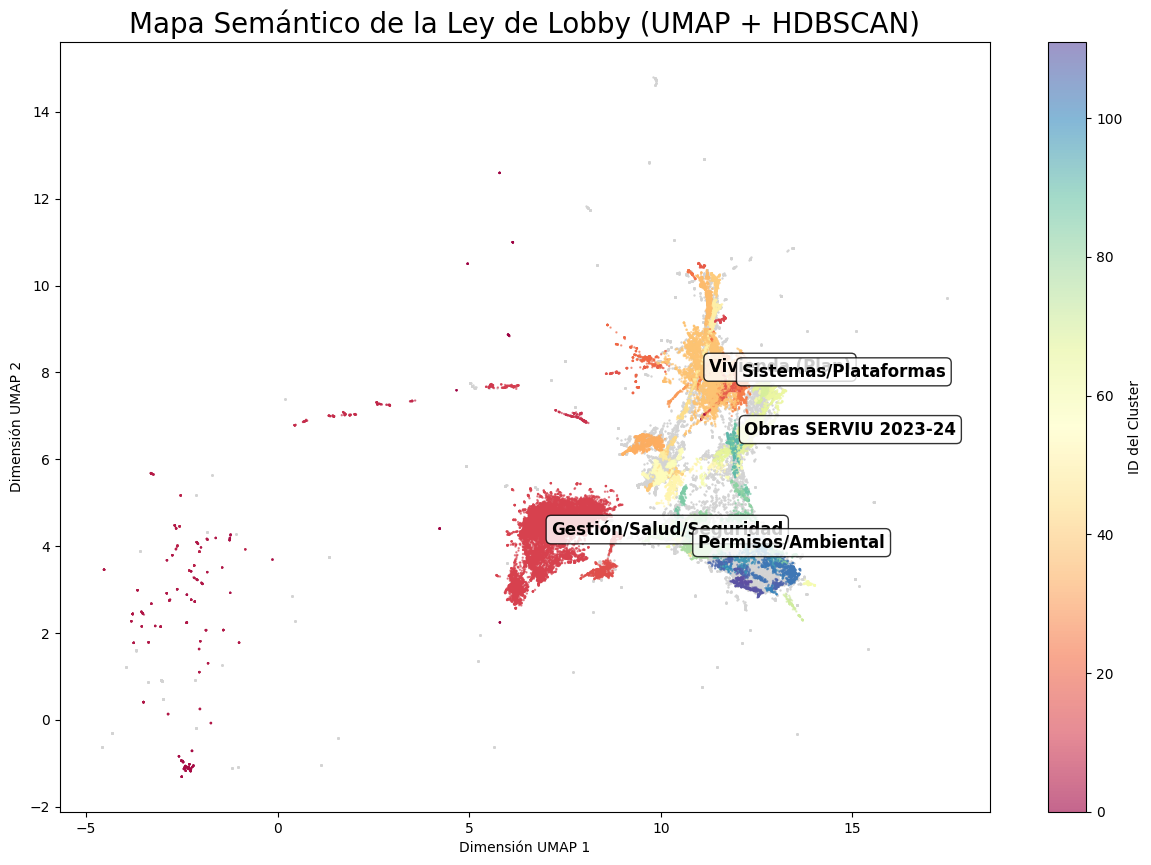

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Preparación de datos para graficar
# umap_embeddings tiene forma (N, 2) o (N, 5). 
# Si usaste n_components=5 en UMAP, tomamos solo las primeras 2 dimensiones para el dibujo.
x = umap_embeddings[:, 0]
y = umap_embeddings[:, 1]

# Configuración del gráfico
plt.figure(figsize=(15, 10))

# 1. Graficamos primero el RUIDO (Cluster -1) en gris y al fondo
mask_noise = labels == -1
plt.scatter(x[mask_noise], y[mask_noise], c='lightgrey', s=0.5, label='Ruido / Sin tema claro')

# 2. Graficamos los CLUSTERS REALES encima
mask_data = labels != -1
scatter = plt.scatter(x[mask_data], y[mask_data], c=labels[mask_data], cmap='Spectral', s=0.5, alpha=0.6)

# Estética
plt.title('Mapa Semántico de la Ley de Lobby (UMAP + HDBSCAN)', fontsize=20)
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')
plt.colorbar(scatter, label='ID del Cluster')

# Opcional: Poner etiquetas de texto en el centro de los clusters grandes
# (Solo para los top 5 que identificamos)
top_clusters = [12, 38, 77, 26, 66]
nombres_clusters = {
    12: "Gestión/Salud/Seguridad",
    38: "Vivienda (Plan)",
    77: "Permisos/Ambiental",
    26: "Sistemas/Plataformas",
    66: "Obras SERVIU 2023-24"
}

for cluster_id in top_clusters:
    # Calculamos el centroide (promedio) de los puntos del cluster
    cluster_points = umap_embeddings[labels == cluster_id]
    cx, cy = np.mean(cluster_points, axis=0)[:2] # Tomamos media de x e y
    
    # Ponemos el texto con fondo blanco para que se lea
    plt.text(cx, cy, nombres_clusters[cluster_id], fontsize=12, fontweight='bold', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round'))

plt.show()

# UMAP - Completo

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

# 1. Configuración
print("=== BLOQUE 1: INICIO ===")
print(f"Total de documentos a procesar: {len(emb_detalle)}")

# 2. Normalización (Vital para coseno/euclidiana)
print("Normalizando embeddings de 'Detalle'...")
emb_input = normalize(emb_detalle)

# 3. PCA (Reducción inicial a 50 dimensiones)
# Esto es necesario para que UMAP no colapse con 768 dimensiones x 1M datos
print("Ejecutando PCA (768 -> 75 dims)...")
pca = PCA(n_components=75, random_state=42)
emb_pca = pca.fit_transform(emb_input)

print(f"PCA Terminado. Shape actual: {emb_pca.shape}")
print("=== BLOQUE 1: LISTO ===")

=== BLOQUE 1: INICIO ===
Total de documentos a procesar: 1153810
Normalizando embeddings de 'Detalle'...
Ejecutando PCA (768 -> 50 dims)...
PCA Terminado. Shape actual: (1153810, 75)
=== BLOQUE 1: LISTO ===


In [48]:
import umap
import numpy as np
import gc # Garbage Collector para liberar memoria

print("=== BLOQUE 2 REPARADO: UMAP HÍBRIDO (ANCHORS) ===")

# 1. Configuración de Lotes
TOTAL_DOCS = len(emb_pca)
TRAIN_SIZE = 400000  # Entrenamos con 200k (suficiente para definir el mapa)
BATCH_SIZE = 100000   # Proyectamos de a 50k para no saturar RAM

print(f"Estrategia: Entrenar con {TRAIN_SIZE} y proyectar el resto en lotes.")

# 2. Seleccionar muestra de entrenamiento (Anchors)
# Usamos una semilla para que siempre sean los mismos
np.random.seed(42)
indices_train = np.random.choice(TOTAL_DOCS, size=TRAIN_SIZE, replace=False)
X_train = emb_pca[indices_train]

# 3. Entrenar el Mapper (El "GPS")
print("1/2: Entrenando el mapa base (Fit)...")
mapper = umap.UMAP(
    n_neighbors=15,
    n_components=25,     # ¡AUMENTO DRÁSTICO! De 10 a 25. Usaremos un tercio de la información de PCA (75).
    min_dist=0.1,
    metric='cosine',
    random_state=42,
    low_memory=True,
    n_jobs=1,
    verbose=True
).fit(X_train)

print("Mapa base aprendido. Liberando memoria temporal...")
del X_train
gc.collect() # Forzamos limpieza de RAM

# 4. Proyectar TODO el dataset en el mapa (Transform)
print("2/2: Proyectando todos los documentos en el mapa (Transform)...")

umap_embeddings_list = []

# Procesamos por lotes para que la barra de memoria no explote
for i in range(0, TOTAL_DOCS, BATCH_SIZE):
    end_i = min(i + BATCH_SIZE, TOTAL_DOCS)
    print(f"   Procesando lote {i} a {end_i} de {TOTAL_DOCS}...", end='\r')
    
    batch = emb_pca[i:end_i]
    batch_emb = mapper.transform(batch) # Aquí ocurre la magia
    umap_embeddings_list.append(batch_emb)

print("\nUniendo lotes...")
umap_embeddings = np.vstack(umap_embeddings_list)

print(f"¡Éxito! Shape final UMAP: {umap_embeddings.shape}")
print("=== BLOQUE 2: LISTO ===")

=== BLOQUE 2 REPARADO: UMAP HÍBRIDO (ANCHORS) ===
Estrategia: Entrenar con 400000 y proyectar el resto en lotes.
1/2: Entrenando el mapa base (Fit)...
UMAP(angular_rp_forest=True, metric='cosine', n_components=25, n_jobs=1, random_state=42, verbose=True)
Thu Nov 27 12:41:00 2025 Construct fuzzy simplicial set
Thu Nov 27 12:41:00 2025 Finding Nearest Neighbors
Thu Nov 27 12:41:00 2025 Building RP forest with 37 trees
Thu Nov 27 12:41:08 2025 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	 3  /  19
	 4  /  19
	 5  /  19
	 6  /  19
	Stopping threshold met -- exiting after 6 iterations
Thu Nov 27 12:41:31 2025 Finished Nearest Neighbor Search
Thu Nov 27 12:41:32 2025 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  10%| █          21/200 [00:24]

	completed  20  /  200 epochs


...

	completed  24  /  30 epochs


Epochs completed:  97%| █████████▋ 29/30 [00:03]

	completed  27  /  30 epochs


Epochs completed: 100%| ██████████ 30/30 [00:03]


Uniendo lotes...
¡Éxito! Shape final UMAP: (1153810, 25)
=== BLOQUE 2: LISTO ===


In [49]:
import hdbscan
import pandas as pd

print("=== BLOQUE 3: HDBSCAN ===")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40,    # REDUCIDO: De 40 a 20. Permite la formación de clusters más pequeños.
    min_samples=15,         # REDUCIDO: De 15 a 10. Menos estricto en la definición de densidad (más inclusivo).
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
    core_dist_n_jobs=1
)

print("Ejecutando clustering sobre 1.15M de datos...")
labels = clusterer.fit_predict(umap_embeddings)

# Reporte rápido
df_temp = pd.DataFrame({'cluster': labels})
n_clusters = len(df_temp['cluster'].unique()) - 1
ruido_pct = (len(df_temp[df_temp['cluster'] == -1]) / len(labels)) * 100

print(f"✅ Clustering terminado.")
print(f"📊 Total Clusters encontrados: {n_clusters}")
print(f"🗑️ Porcentaje de Ruido: {ruido_pct:.2f}%")
print("=== BLOQUE 3: LISTO ===")

/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/.conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/.conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


=== BLOQUE 3: HDBSCAN ===
Ejecutando clustering sobre 1.15M de datos...
✅ Clustering terminado.
📊 Total Clusters encontrados: 3036
🗑️ Porcentaje de Ruido: 65.75%
=== BLOQUE 3: LISTO ===


In [53]:
import numpy as np
import pandas as pd

print("=== BLOQUE 4: AISLAMIENTO Y PREPARACIÓN DEL RUIDO ===")

# 1. Identificar los índices del cluster de ruido (-1)
# 'labels' es el array generado por HDBSCAN
indices_ruido = np.where(labels == -1)[0]
n_ruido = len(indices_ruido)

print(f"Número de elementos a re-clusterizar (Ruido): {n_ruido}")

# 2. Aísla los embeddings UMAP correspondientes al ruido
# X_ruido_umap será la matriz de entrada para MiniBatchKMeans
X_ruido_umap = umap_embeddings[indices_ruido] 

# 3. Crear el sub-DataFrame de referencia
# Esto es crucial para la integración. Contiene el índice original de las filas de ruido en 'df'.
df_ruido_hibrido = df.iloc[indices_ruido].copy() 

print(f"Shape de la matriz de ruido para K-Means: {X_ruido_umap.shape}")
print("=== BLOQUE 4: LISTO ===")

=== BLOQUE 4: AISLAMIENTO Y PREPARACIÓN DEL RUIDO ===
Número de elementos a re-clusterizar (Ruido): 758584
Shape de la matriz de ruido para K-Means: (758584, 25)
=== BLOQUE 4: LISTO ===


=== BLOQUE 5: ENCONTRANDO K ÓPTIMO ===
Calculando Inercia para el Método del Codo (MiniBatchKMeans)...


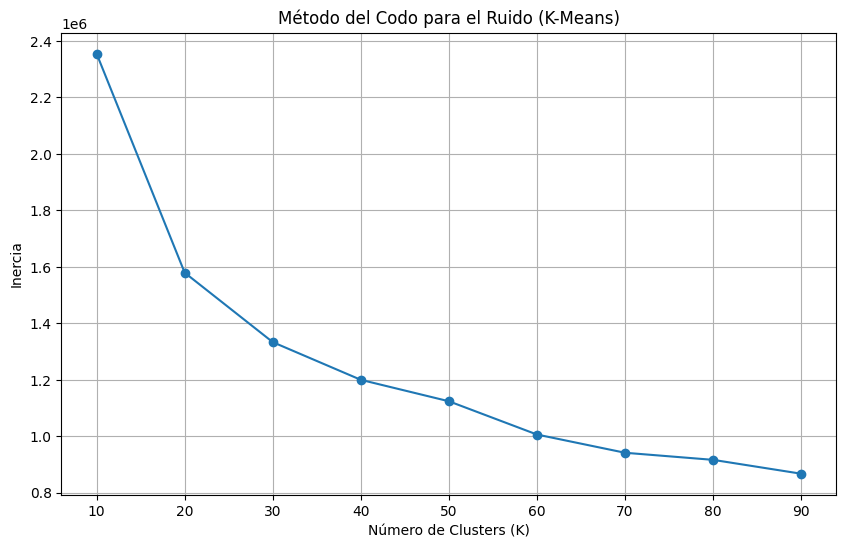


✅ Análisis del Codo completado. Por favor, asigna k_optimo en el código (valor actual: 40).
=== BLOQUE 5: LISTO ===


In [56]:
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

print("=== BLOQUE 5: ENCONTRANDO K ÓPTIMO ===")

# Configuración del rango de K a probar (Ajusta este rango según necesidad)
rango_k = range(10, 100, 10) 
inercia = []

print("Calculando Inercia para el Método del Codo (MiniBatchKMeans)...")

for k in rango_k:
    # Usamos MiniBatchKMeans para la eficiencia en el subconjunto grande
    mbk = MiniBatchKMeans(n_clusters=k, random_state=42, n_init='auto', batch_size=2048)
    mbk.fit(X_ruido_umap)
    inercia.append(mbk.inertia_)
    print(f"  K={k} completado.", end='\r')

# 1. Visualización (Si estás en un entorno compatible)
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o')
plt.title('Método del Codo para el Ruido (K-Means)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

# 2. ASIGNACIÓN MANUAL:
# Revisa la gráfica y asigna el punto de inflexión a k_optimo.
k_optimo = 40 # <-- DEBES REEMPLAZAR 50 CON EL VALOR QUE OBSERVES EN LA GRÁFICA

print(f"\n✅ Análisis del Codo completado. Por favor, asigna k_optimo en el código (valor actual: {k_optimo}).")
print("=== BLOQUE 5: LISTO ===")

In [58]:
from sklearn.cluster import MiniBatchKMeans

print("=== BLOQUE 6: RE-CLUSTERING E INTEGRACIÓN FINAL ===")

# 1. EJECUCIÓN DE K-MEANS
print(f"Ejecutando MiniBatchKMeans con K={k_optimo}...")
kmeans_hibrido = MiniBatchKMeans(
    n_clusters=k_optimo,
    random_state=42,
    batch_size=2048,
    n_init='auto'
)
nuevas_etiquetas = kmeans_hibrido.fit_predict(X_ruido_umap)

# 2. RENUMEACIÓN
# Aseguramos que los nuevos clusters no colisionen con los 3070 clusters de HDBSCAN.
max_etiqueta_existente = np.max(labels) # Máxima etiqueta del clustering HDBSCAN
etiqueta_inicio = max_etiqueta_existente + 1 

# Esta es la variable crucial que se usó en el error anterior
etiquetas_renumeradas = nuevas_etiquetas + etiqueta_inicio

print(f"Clusters renumerados: {etiquetas_renumeradas.min()} a {etiquetas_renumeradas.max()}")

# 3. INTEGRACIÓN AL DATAFRAME FINAL
# a. Inicializar la nueva columna 'cluster' con las etiquetas de HDBSCAN (incluyendo -1)
df['cluster'] = labels.astype('int64')

# b. Sobreescribir los valores -1 con las nuevas etiquetas renumeradas
indices_a_actualizar = df_ruido_hibrido.index
df.loc[indices_a_actualizar, 'cluster'] = etiquetas_renumeradas

# 4. REPORTE FINAL DE LA INTEGRACIÓN
ruido_final = len(df[df['cluster'] == -1])
total_clusters_final = len(df['cluster'].unique()) - 1 # Se resta el -1

print("\n--- RESULTADO FINAL ---")
print(f"✅ Integración completada. Ruido remanente: {ruido_final}")
print(f"Total de Clusters (Alta Calidad + Híbridos): {total_clusters_final}")
print(df['cluster'].value_counts().sort_index().head(20)) 
print("=== BLOQUE 6: LISTO ===")

=== BLOQUE 6: RE-CLUSTERING E INTEGRACIÓN FINAL ===
Ejecutando MiniBatchKMeans con K=40...
Clusters renumerados: 3036 a 3075

--- RESULTADO FINAL ---
✅ Integración completada. Ruido remanente: 0
Total de Clusters (Alta Calidad + Híbridos): 3075
cluster
0     119
1      94
2      82
3      59
4     109
5      79
6      77
7      54
8      62
9      49
10     44
11     51
12     83
13    113
14     56
15    122
16     83
17    196
18     75
19     61
Name: count, dtype: int64
=== BLOQUE 6: LISTO ===


In [59]:
df

,pasivo_id,activo_id,temas,detalle,cluster
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...,3037
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...,3061
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...,3042
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...,3048
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...,3068
...,...,...,...,...,...
1153805,391700,JAIME OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL,1798
1153806,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL,657
1153807,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL,2187
1153808,712954,Margarita Corrotea,"Diseño, implementación y evaluación de polític...","encomendada compañía ESVAL, entregar informaci...",3067


In [60]:
import pandas as pd

# Definir el rango de las nuevas etiquetas híbridas
etiqueta_min = 3036
etiqueta_max = 3075

# 1. Aplicar la condición booleana para filtrar las filas dentro del rango
# (Cluster >= 3036) AND (Cluster <= 3075)
nuevos_clusters_hibridos = df[
    (df['cluster'] >= etiqueta_min) & 
    (df['cluster'] <= etiqueta_max)
]

# 2. Contar el total de documentos re-etiquetados
conteo_total_hibrido = len(nuevos_clusters_hibridos)

# 3. Contar la distribución por cada nuevo cluster
distribucion_hibrida = nuevos_clusters_hibridos['cluster'].value_counts().sort_index()

print("=== VERIFICACIÓN DE CLUSTERS HÍBRIDOS ===")
print(f"✅ Total de Documentos Re-etiquetados (Clusters 3036 a 3075): {conteo_total_hibrido}")
print(f"🗑️ El ruido original era de aproximadamente 758.537 documentos.")
print("------------------------------------------")
print("📊 Distribución de Documentos por Nuevo Cluster:")
print(distribucion_hibrida)

# Opcional: Graficar la distribución
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 6))
# distribucion_hibrida.plot(kind='bar')
# plt.title('Distribución de Documentos en Clusters Híbridos (3036-3075)')
# plt.xlabel('Etiqueta de Cluster')
# plt.ylabel('Número de Documentos')
# plt.show()

=== VERIFICACIÓN DE CLUSTERS HÍBRIDOS ===
✅ Total de Documentos Re-etiquetados (Clusters 3036 a 3075): 758584
🗑️ El ruido original era de aproximadamente 758.537 documentos.
------------------------------------------
📊 Distribución de Documentos por Nuevo Cluster:
cluster
3036    23696
3037    20088
3038    25065
3039    16984
3040    19922
3041    19752
3042    27306
3043     3319
3044    33329
3045    12907
3046    25745
3047     3184
3048    28966
3049    17051
3050    16177
3051    24984
3052    25538
3053    10460
3054    18482
3055    23490
3056    18464
3057     9071
3058    15416
3059    20789
3060    12399
3061    21771
3062     8302
3063     2402
3064    23125
3065    17490
3066    12901
3067    14092
3068    33726
3069    24916
3070    16140
3071    21836
3072    34876
3073    16030
3074    23687
3075    14706
Name: count, dtype: int64


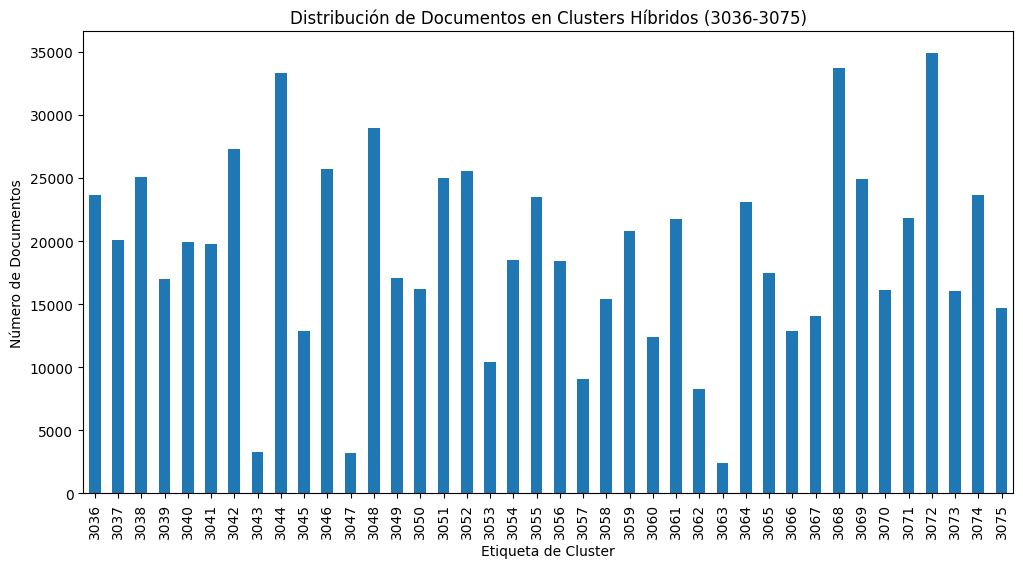

In [61]:
# Opcional: Graficar la distribución
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
distribucion_hibrida.plot(kind='bar')
plt.title('Distribución de Documentos en Clusters Híbridos (3036-3075)')
plt.xlabel('Etiqueta de Cluster')
plt.ylabel('Número de Documentos')
plt.show()

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import re # Importamos expresiones regulares

# Descargar stopwords en español si no las tienes
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

print("=== BLOQUE 7 (MEJORADO): CONFIGURACIÓN DE STOP WORDS ===")

# 1. Stop words estándar
stop_words_es = stopwords.words('spanish')

# 2. Frase de ruido original
frase_ruido = "Elaboración, dictación, modificación, denegación o rechazo de actos administrativos, proyectos de ley y leyes y también de las decisiones que tomen los sujetos pasivos"
palabras_ruido_especifico = frase_ruido.lower().replace(',', '').split()

# 3. Stop Words Burocráticas (Tu lista original)
burocracia_words = [
    "solicita", "solicitud", "solicitar", "pide", "requiere", "realizar", 
    "reunión", "audiencia", "cita", "encuentro", "presentación", "conversar",
    "tratar", "temas", "tema", "materia", "materias", "sobre", "respecto",
    "informar", "información", "gestión", "gestionar", "apoyo", "ayuda",
    "señor", "sr", "sra", "don", "doña", "parte", "sujeto", "pasivo",
    "autoridad", "jefe", "director", "encargado", "delegado", "seremi",
    "vecinos", "comunidad", "grupo", "asociación", "comité",
    "documento", "oficio", "ordinario", "carta", "memo", "adjunto", "archivo",
    "antecedentes", "copia", "expediente", "folio",
    "día", "fecha", "hora", "hoy", "ayer", "mañana", "mes", "año",
    "lugar", "sector", "comuna", "región", "provincia",
    "ley", "proyecto", "programa", "plan", "caso", "situación", "problema"
]

# 4. NUEVA LIMPIEZA: HTML y Palabras Genéricas Dominantes
# Estas palabras aparecieron en tus resultados tapando los temas reales
basura_html_generica = [
    "br", "li", "ul", "div", "span", "class", "style", # Basura HTML
    "empresa", "empresas", "trabajo", "trabajos", "servicio", "servicios",
    "nacional", "regional", "chile", "país", "zona",
    "desarrollo", "proceso", "evaluación", "generación", # Muy abstractas
    "serviu", "minvu", "mop", "cmn", "sag" # Instituciones que aparecen en todo (opcional)
]

# 5. UNIFICACIÓN
mis_stop_words = set(stop_words_es + palabras_ruido_especifico + burocracia_words + basura_html_generica)

print(f"✅ Configuración lista. Stop Words actualizadas (incluye 'br' y 'empresa').")
print(f"Total palabras a ignorar: {len(mis_stop_words)}")
print("=== BLOQUE 7: LISTO ===")

=== BLOQUE 7 (MEJORADO): CONFIGURACIÓN DE STOP WORDS ===
✅ Configuración lista. Stop Words actualizadas (incluye 'br' y 'empresa').
Total palabras a ignorar: 427
=== BLOQUE 7: LISTO ===


In [68]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== BLOQUE 8 (MEJORADO): GENERACIÓN DE PALABRAS CLAVE ===")

# 0. LIMPIEZA PREVIA DE HTML EN EL DATAFRAME
# Esto elimina los <br> del texto fuente para que no molesten más
print("Limpiando etiquetas HTML residuales...")
df['detalle'] = df['detalle'].fillna("").astype(str)
# Reemplaza 'br' y etiquetas html por espacio
df['detalle'] = df['detalle'].str.replace(r'<[^>]+>', ' ', regex=True) 

# 1. AGRUPACIÓN
print("Agrupando textos por cluster...")
docs_per_class = df.groupby(['cluster'], as_index=False).agg({'detalle': ' '.join})

# 2. CÁLCULO DE TF-IDF
print("Calculando TF-IDF con nuevas stop words...")
tfidf = TfidfVectorizer(
    stop_words=list(mis_stop_words),
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

c_tf_idf = tfidf.fit_transform(docs_per_class['detalle'])
words = tfidf.get_feature_names_out()

# 3. EXTRACCIÓN
print("Extrayendo keywords...")
def get_top_n_words(tfidf_matrix, feature_names, n=10):
    cluster_keywords = {}
    dense = tfidf_matrix.todense()
    for i in range(len(dense)):
        row = dense[i].tolist()[0]
        top_indices = sorted(range(len(row)), key=lambda i: row[i], reverse=True)[:n]
        top_words = [feature_names[idx] for idx in top_indices if row[idx] > 0]
        cluster_keywords[docs_per_class['cluster'][i]] = ", ".join(top_words)
    return cluster_keywords

keywords_dict = get_top_n_words(c_tf_idf, words, n=10)

print(f"✅ Nuevas palabras clave generadas sin 'br'.")
print("=== BLOQUE 8: LISTO ===")

=== BLOQUE 8 (MEJORADO): GENERACIÓN DE PALABRAS CLAVE ===
Limpiando etiquetas HTML residuales...
Agrupando textos por cluster...
Calculando TF-IDF con nuevas stop words...
Extrayendo keywords...
✅ Nuevas palabras clave generadas sin 'br'.
=== BLOQUE 8: LISTO ===


In [69]:
print("=== BLOQUE 9: INTEGRACIÓN Y VALIDACIÓN ===")

# 1. Mapear las keywords al DataFrame principal
df['keywords'] = df['cluster'].map(keywords_dict)

# 2. Visualización de Muestras
# Vamos a ver qué encontró para los clusters originales (densos) y los nuevos (híbridos)

print("\n--- MUESTRA: CLUSTERS ORIGINALES (HDBSCAN) ---")
# Tomamos 3 ejemplos aleatorios de clusters menores a 3036
if len(df[df['cluster'] < 3036]) > 0:
    ejemplo_orig = df[df['cluster'] < 3036].sample(3)
    for idx, row in ejemplo_orig.iterrows():
        print(f"Cluster {row['cluster']}: [{row['keywords']}]")
        print(f"   --> Texto Real: {str(row['detalle'])[:100]}...")
        print("-" * 30)

print("\n--- MUESTRA: CLUSTERS HÍBRIDOS (K-MEANS) ---")
# Tomamos 3 ejemplos aleatorios de clusters mayores o iguales a 3036 (el antiguo ruido)
if len(df[df['cluster'] >= 3036]) > 0:
    ejemplo_hibrido = df[df['cluster'] >= 3036].sample(3)
    for idx, row in ejemplo_hibrido.iterrows():
        print(f"Cluster {row['cluster']}: [{row['keywords']}]")
        print(f"   --> Texto Real: {str(row['detalle'])[:100]}...")
        print("-" * 30)

print("=== BLOQUE 9: LISTO ===")

=== BLOQUE 9: INTEGRACIÓN Y VALIDACIÓN ===

--- MUESTRA: CLUSTERS ORIGINALES (HDBSCAN) ---
Cluster 2153: [hormigón, salares norte, salares, asistentes da, da inicio, rut, subsecretario, concurso, resumen acta, clasificación]
   --> Texto Real: 1. Rechazo PMOOCC ingresado a tramitación con calidad de concesionario ( Res. 1002030/O-012; DL 701/...
------------------------------
Cluster 1663: [mora, coronel, cabras, villa, construcción, registro civil, 03 2022, área, casablanca, 2022]
   --> Texto Real: CONSTRUCCIÓN...
------------------------------
Cluster 722: [vecino, concordancia, derecho, extracción, analizó, núcleo, 40, fon, descanso, implementados]
   --> Texto Real: Representantes de la Empresa realizan pesentación de Pertinencia para cambio en sistemas de tratamie...
------------------------------

--- MUESTRA: CLUSTERS HÍBRIDOS (K-MEANS) ---
Cluster 3048: [ambiental, división, agua, presentar, pesca, asisten, salud, medio, conocer, consulta]
   --> Texto Real: Sobre ingreso de l

In [70]:
print("=== BLOQUE 10: ETIQUETADO FINAL ===")

def generar_etiqueta_corta(keywords_str):
    if not isinstance(keywords_str, str):
        return "Sin Tema"
    # Tomamos las primeras 3 palabras clave
    partes = keywords_str.split(',')[:3]
    # Las unimos con guiones y quitamos espacios
    return "-".join([p.strip() for p in partes])

# 1. Crear la etiqueta corta
df['cluster_label'] = df['keywords'].apply(generar_etiqueta_corta)

# 2. Crear una columna que combine ID y Label (ej: "3039: soluciones-digital-seguridad")
# Esto es muy útil para gráficos
df['cluster_full_name'] = df['cluster'].astype(str) + ": " + df['cluster_label']

# Muestra final
print(df[['cluster', 'cluster_label', 'detalle']].head(10))
print("=== BLOQUE 10: LISTO ===")

=== BLOQUE 10: ETIQUETADO FINAL ===
   cluster                      cluster_label  \
0     3037  presentar-personal personal-salud   
1     3061      educación-estudiantes-escolar   
2     3042                 poder-respuesta-si   
3     3048            ambiental-división-agua   
4     3068            presentar-conocer-salud   
5     3056           presentar-salud-cenabast   
6     2321             nuevo-nueva-protocolar   
7     3052            presentar-salud-conocer   
8     3052            presentar-salud-conocer   
9     3052            presentar-salud-conocer   

                                             detalle  
0  Reunión con el cuerpo colegiado del ADI y CNA ...  
1  Socios de JJVV de Caquena solicitan audiencia ...  
2  Audiencia con Delegado Presidencial Provincial...  
3  Presentación como Asociación de Ganaderos al D...  
4  Audiencia con el Delegado Presidencial Provinc...  
5  Audiencia con el Delegado para hablar sobre Nu...  
6  Grupo Aguas Nuevas adquirió Aguas Ch

In [71]:
df.head(10)

,pasivo_id,activo_id,temas,detalle,cluster,keywords,cluster_label,cluster_full_name
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...,3037,"presentar, personal personal, salud, personal,...",presentar-personal personal-salud,3037: presentar-personal personal-salud
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...,3061,"educación, estudiantes, escolar, social, funda...",educación-estudiantes-escolar,3061: educación-estudiantes-escolar
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...,3042,"poder, respuesta, si, ser, presentar, usted, s...",poder-respuesta-si,3042: poder-respuesta-si
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...,3048,"ambiental, división, agua, presentar, pesca, a...",ambiental-división-agua,3048: ambiental-división-agua
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...,3068,"presentar, conocer, salud, terreno, poder, soc...",presentar-conocer-salud,3068: presentar-conocer-salud
5,769978,EDUARDO CAYUPI VELIZ,"Elaboración, dictación, modificación, denegaci...",Audiencia con el Delegado para hablar sobre Nu...,3056,"presentar, salud, cenabast, terreno, personal,...",presentar-salud-cenabast,3056: presentar-salud-cenabast
6,189490,Carlos Barboza,"Diseño, implementación y evaluación de polític...","Grupo Aguas Nuevas adquirió Aguas Chañar, pres...",2321,"nuevo, nueva, protocolar, presentar, general, ...",nuevo-nueva-protocolar,2321: nuevo-nueva-protocolar
7,189490,Carlos Brito,"Celebración, modificación o terminación a cual...",Presentarse y abordar temas de proyectos pasados.,3052,"presentar, salud, conocer, ambiental, social, ...",presentar-salud-conocer,3052: presentar-salud-conocer
8,189490,Andrea Rosa Acuña Retamar,"Elaboración, dictación, modificación, denegaci...",Presentación a la autoridad del Proyecto Salar...,3052,"presentar, salud, conocer, ambiental, social, ...",presentar-salud-conocer,3052: presentar-salud-conocer
9,189490,Sebastián Gallardo,"Elaboración, dictación, modificación, denegaci...",Presentación a la autoridad del Proyecto Salar...,3052,"presentar, salud, conocer, ambiental, social, ...",presentar-salud-conocer,3052: presentar-salud-conocer
